# Classificador Naive Bayes
====================================================
#### Criaturas Lendárias do reino de Lumi - A Esfinge
**Disciplina:** Aprendizado de Máquina - Ilum Escola de Ciência

**Autor:** Luis Navarro Erbetta

### Introdução

O Naive bayes é um tipo de algoritmo de aprendizado de máquina supervisionado, muito utilizado para tarefas de classificação. Ele pertence a uma grande classe chamada de algoritmos generativos, de modo que ele tenta modelar a distribuição das probabilidades dos dados de cada classe ao invés de aprender diretamente qual característica melhor as separa.

Ele recebe o nome de "ingênuo" ("naive", em inglês) pois parte de uma suposição de que todas as variáveis são independentes entre si, o que muitas vezes não acontece na vida real. Apesar dessa simplificação, o algoritmo se prova bem eficaz em aplicações reais, principalmente quando se trata de conjuntos de dados pequenos e com alta dimensionalidade. 

Nesse notebook vamos passar pelos seguintes tópicos:

- Revisão dos conceitos de probabilidade condicional e Teorema de Bayes;
- Formalizar a regra de classificação do modelo; 
- Entender por que o algoritmo é "ingênuo" e como funciona seu algoritmo de decisão;
- Conhecer as principais variantes (Gaussiana, Multinominal, Complementar e outras);
- Resolução de um exemplo numérico;
- Aplicar o algoritmo em um conjunto de dados numéricos e um conjunto de dados de texto;
- Investigar a influência de hiperparâmetros; 
- Comparar com o modelo KNN (k-vizinhos mais próximos);
- Discutir vantagens e limitações do modelo. 

### Carregando bibliotecas

Nessa seção estaremos apenas importando todas as bibliotecas que serão utilizadas ao longo do notebook.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

### Probabilidade condicional e Teorema de Bayes

A probabilidade condicional representa e calcula as chances de um evento A acontecer, dado um evento B anterior. Em linguagem matemática podemos escrever da seguinte maneira: 

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$ 

Já o Teorema de Bayes (ou Regra de Bayes) modifica um pouco essa equação, de modo que ele permite "inverter" essa relação, calculando `P(B|A)` a partir de `P(A|B)`. A nova equação é escrita da seguinte forma:

$$
P(B \mid A) = \frac{P(A \mid B)\, P(B)}{P(A)}
$$

Agora devemos esclarescer o que cada termo das equações representam:

- $P(A \mid B)$: é a probabilidade de o evento A ser verdadeiro, dado que B é verdadeiro;
- $P(B \mid A)$: é a probabilidade de o evento B ser verdadeiro, dado que A é verdadeiro;
- $P(A)$: representa a probabilidade *a priori* de A, antes de considerar o evento B;
- $P(B)$: representa a probabilidade *a priori* de B, antes de considerar o evento A.

Em outras palavras, $P(A\mid B)$ e $P (B\mid A)$ são as probabilidades *a posteriori* e $P(A)$ e $P(B)$ são as probabilidades *a priori*. Mas o que isso quer dizer?

A probabilidade *a priori* é a probabilidade inicial de um evento antes de ser analisado o contexto em que ele está inserido. Já a probabilidade *a posteriori* é a probabilidade de um evento após a análise de um  outro dado.

Para exemplificar melhor esse conceito, podemos pensar em um teste médico. Imagine que o professor Daniel Cassar fez um teste para saber se possui uma certa doença. Vamos dizer que  probabilidade geral de se ter essa doença seja 5%, essa então será a probabilidade *a priori*. Porém, se o teste der positivo, a probabilidade *a priori* é então atualizada para levar essa nova informação em conta, se tornando uma probabilidade *a posteriori*.

Assim, no exemplo dado, temos `P(doente) = 0,05` sendo essa a probabilidade *a priori* e `P(doente|positivo)` a probabilidade *a posteriori*. Essa ideia de atualização de parâmetros é o conceito que está por trás do algoritmo Naive Bayes. 

### Do teorema para o algoritmo

Para isso, vamos imaginar outro cenário. Imagine que você comprou um vinho e gostaria de saber a qual classe $y$ ele pertence: os secos, meio-secos ou doces. Para descobrir, vão ser analisadas diferentes características:

$$
\begin{aligned}
x_1 &: \text{teor alcoólico} \\
x_2 &: \text{acidez} \\
x_3 &: \text{intensidade da cor} \\
&\vdots \\
x_n &
\end{aligned}
$$

O classificador irá calcular:

$$
P(y \mid x_1, \dots, x_n)
$$

Que significa "qual a probabilidade de meu vinho pertencer a classe $y$ visto que analisei os atributos $x_1, \dots, x_n$?"

Ao tentar descobrir a resposta pelo Teorema de Naive Bayes temos: 

$$
P(y \mid x_1, \dots, x_n) = \frac{P(y)\, P(x_1, \dots, x_n \mid y)}{P(x_1, \dots, x_n)}
$$

Porém, calcular isso se torna inviável por conta do termo $P(x_1, \dots, x_n \mid y)$, visto que seria necessário conhecer a distribuição de todos os atributos para cada classe.

### A suposição ingênua do algoritmo

O algoritmo Naive Bayes assume que, dado o valor da classe, todos os atributos são condicionalmente independentes entre si. Em outras palavras, saber o valor de um dos atributos não muda a probabilidade dos demais, uma vez que já sabemos a classe, o que pode ser escrito matematicamente da seguinte forma:

$$
P(x_i \mid y, x_1, \dots, x_{i-1}, x_{i+1}, \dots, x_n) = P(x_i \mid y), \quad \forall i
$$

Sabemos que na vida real isso raramente acontece, mas interpretar as situações com essa suposição é uma maneira de reduzir drasticamente o custo computacional, visto que ela transforma uma distribuição conjunta complexa em várias atribuições unidimensionais. 

Com essa suposição, surge a fórmula:

$$
P(y \mid x_1, \dots, x_n) \;\propto\; P(y) \prod_{i=1}^{n} P(x_i \mid y)
$$

Como o denominador $P(x_1, \dots, x_n)$ é constante para uma dada observação (não depende da classe $y$), ele pode ser descartado quando compararmos as classes entre si. Com isso, chegamos a chamada **Regra de Decisão do Naive Bayes**, essa que é baseada na estimativa de **Máxima Probabilidade a Posteriori** (MAP): 

$$
\hat{y} = \arg\max_{y} \; P(y) \prod_{i=1}^{n} P(x_i \mid y)
$$

Essa fórmula mostra que a classe prevista é aquela que maximiza o produto entre a probabilidade *a priori* das classes e as probabilidades condicionais de cada atributo dada essa classe. 

Um ponto importante que devemos tratar é que na prática, multiplicar muitas probabilidades pequenas pode causar problemas numéricos (*underflow*). Por isso, é comum somar os logaritmos ao invés de multiplicar as probabilidades:

$$
\hat{y} = \arg\max_{y} \; \left[\log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y) \right]
$$

Assim, treinar o modelo consiste em estimar duas quantidades a partir dos dados:

- A probabilidade *a priori* de cada classe $P(y)$, normalmente calculada pela frequência relativa de cada classe no conjunto de treino (estimativa de máxima verossimilhança);
- As probabilidades condicionais $P(x_i \mid y)$, que também são chamadas de verossimilhança de classe, representam a probabilidade de observar cada atributo dado que a observação pertence a classe $y$

### Principais variantes do Naive Bayes

O nome "Naive Bayes" não e refere apenas a um algoritmo, mas sim a uma família de algoritmos que possuem a mesma estrutura geral (Teorema de Bayes + probabilidade condicionais independentes), mas se diferem nas maneiras de classificar a distribuição $P(x_i \mid y)$. Todas as variantes que serão mostradas abaixo estão implementadas no módulo `sklearn.naive_bayes` da biblioteca scikit-learn.

| Variante | Tipo de atributo | Ideia central | Exemplo típico |
|---|---|---|---|
| **Gaussiano** (`GaussianNB`) | Contínuo | Assume distribuição normal por classe | Medidas de flores (Iris) |
| **Multinomial** (`MultinomialNB`) | Contagens | Frequência relativa suavizada de cada atributo | Contagem de palavras em textos |
| **Complementar** (`ComplementNB`) | Contagens | Como o Multinomial, mas usa estatísticas do complemento da classe | Textos com classes desbalanceadas |
| **Bernoulli** (`BernoulliNB`) | Binário (0/1) | Só considera presença/ausência, penaliza ausências | Presença/ausência de palavras |
| **Categórico** (`CategoricalNB`) | Categórico não ordenado | Distribuição categórica por atributo e por classe | Cor, tipo, região |

#### 1. Naive Bayes Guassiano (GuassianNB)

Utilizado quando os atributos são contínuos, ele assume que dentro de cada classe os dados possuem uma distribuição normal (distribuição guassiana):

$$
P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)
$$

Os parâmetros $\mu_y$ (média) e $\sigma_y$ (desvio padrão) são estimados diretamente dos dados de treino para cada classe. Um exemplo típico é usar medidas de flores (comprimento e largura de pétalas e sépalas) para prever a espécie — o clássico conjunto de dados *Iris*.

A célula de código a seguir ilustra a ideia com duas classes fictícias e dois atributos contínuos: cada classe recebe sua própria "nuvem" gaussiana, e uma nova observação é classificada de acordo com qual nuvem lhe atribui maior densidade de probabilidade.

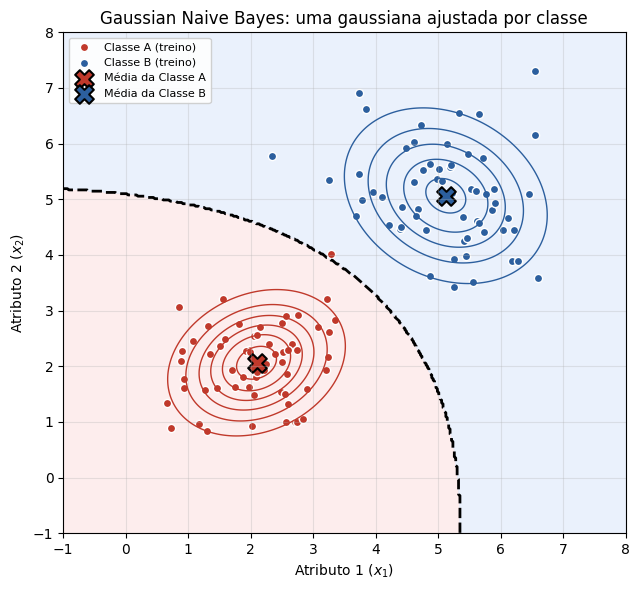

In [2]:
np.random.seed(42)

# Duas classes fictícias em 2D, cada uma com sua gaussiana
classe0 = np.random.multivariate_normal([2, 2], [[0.6, 0.2], [0.2, 0.6]], 60)
classe1 = np.random.multivariate_normal([5, 5], [[0.8, -0.3], [-0.3, 0.8]], 60)

mu0, cov0 = classe0.mean(axis=0), np.cov(classe0.T)
mu1, cov1 = classe1.mean(axis=0), np.cov(classe1.T)

def gaussiana_2d(x, y, mu, cov):
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    d = np.stack([x - mu[0], y - mu[1]], axis=-1)
    expo = -0.5 * np.einsum('...i,ij,...j->...', d, inv, d)
    return (1.0 / (2 * np.pi * np.sqrt(det))) * np.exp(expo)

xx, yy = np.meshgrid(np.linspace(-1, 8, 400), np.linspace(-1, 8, 400))
p0 = gaussiana_2d(xx, yy, mu0, cov0)
p1 = gaussiana_2d(xx, yy, mu1, cov1)

fig, ax = plt.subplots(figsize=(6.5, 6))

# Regiao de decisao (fronteira onde p0 == p1)
regiao = (p1 > p0).astype(int)
ax.contourf(xx, yy, regiao, levels=[-0.5, 0.5, 1.5],
            colors=['#fde2e2', '#dce8fb'], alpha=0.6)

# Curvas de nivel das gaussianas 
ax.contour(xx, yy, p0, levels=6, colors='#c0392b', linewidths=1)
ax.contour(xx, yy, p1, levels=6, colors='#2c5f9e', linewidths=1)

# Fronteira de decisao
ax.contour(xx, yy, regiao, levels=[0.5], colors='black', linewidths=2, linestyles='--')

ax.scatter(classe0[:, 0], classe0[:, 1], c='#c0392b', edgecolor='white', s=35, label='Classe A (treino)')
ax.scatter(classe1[:, 0], classe1[:, 1], c='#2c5f9e', edgecolor='white', s=35, label='Classe B (treino)')
ax.scatter(*mu0, c='#c0392b', marker='X', s=180, edgecolor='black', linewidth=1.5, label='Média da Classe A')
ax.scatter(*mu1, c='#2c5f9e', marker='X', s=180, edgecolor='black', linewidth=1.5, label='Média da Classe B')

ax.set_title('Gaussian Naive Bayes: uma gaussiana ajustada por classe', fontsize=12)
ax.set_xlabel('Atributo 1 ($x_1$)')
ax.set_ylabel('Atributo 2 ($x_2$)')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 8)
plt.tight_layout()
plt.show()

As curvas de nível representam a densidade de cada gaussiana (mais escura no centro, onde a densidade é maior). A linha tracejada preta é a fronteira de decisão: pontos à esquerda dela têm maior densidade sob a Classe A (vermelho); à direita, maior densidade sob a Classe B (azul).

#### 2. Naive Bayes Multinomial (MultinomialNB) 

É uma das variantes mais utilizadas para classificação de textos, usado quando os dados representam contagens (quantas vezes uma palavra aparece em um documento, por exemplo), de modo que cada palavra (atributo) é estimada por uma contagem relativa suavizada:

$$
\hat{\theta}_{yi} = \frac{N_{yi} + \alpha}{N_y + \alpha n}
$$

Na quanl $N_yi$ é a quantidade de vezes que uma palavra $i$ aparece no documento de classe $y$, $N_y$ é o total de palavras da classe $y$, $n$ é a quantidade de atributos e $\alpha$ é o parâmetro de suavização

#### 3. Naive Bayes Complementar (ComplementNB)

É uma adaptação do Naive Bayes Multinomial pensada para conjuntos de dados desbalanceados. Em vez de usar estatísticas da própria classe, ela calcula os pesos do modelo a partir das estatísticas do complemento de cada classe (ou seja, de todos os documentos que *não* pertencem àquela classe), o que tende a gerar estimativas mais estáveis e, em geral, apresenta desempenho superior ao Naive Bayes Multinomial em tarefas de classificação de texto.

#### 4. Naive Bayes Bernoulli (BernoulliNB)

É usado para a classificação binário de atributos (0/1 ou verdadeiro/falso). Diferente do Multinomial que trabalha com contagens de ocorrência, esse método considera apenas se uma característica ocorre ou não (se uma palavra aparece ou não em um documento, independente do número de vezes, por exemplo). Outra importante diferença com o Multinomial é que o Bernoulli *penaliza* a ausência de uma característica esperada para um classe, enquanto o Multinomial apenas ignora atributos que não aparecem. 

#### 5. Naive Bayes Categórico

Voltado para atributos categóricos (não podem ser ordenados), em que cada variável possui sua própria distribuição categórica condicionada à classe. É útil, por exemplo, quando as variáveis representam categorias como "cor" ou "tipo", sem uma relação de ordem entre os valores.

### Problema da frequência zero e suavização de Laplace

Como o Naive Bayes multiplica as probabilidades condicionais de todos os atributos, se um único atributo não aparecer em uma classe durante o treinamento do algoritmo, sua probabilidade estimada será zero, o que anularia toda a probabilidade *a posteriori* daquela classe. Esse fenômeno é chamado de Problema da Frequência zero.

Para resolver isso, usa-se a suavização de Laplace, que consiste em somar uma pequena constante $\alpha$ (a mesma constante do Naive Bayes Multinomial) ao numerador e ao denominador, garantindo assim que nenhuma probabilidade condicional seja nula.  

### Resolvendo um exemplo numérico passo a passo

Para exemplificar os conceitos vistos até agora, iremos resolver um problema usando um cenário de Fórmula 1. Considere dados fictícios de 20 corridas, levando em consideração o **tipo de circuito** (rápido ou lento) e a **equipe vencedora** (Ferrari ou McLaren): 

| | Ferrari vence ($A_1$) | McLaren vence ($A_2$) | Total de Vitórias |
|---|---|---|---|
|**Circuito rápido ($B_1$)**|4|9|13|
|**Circuito lento ($B_2$)**|5|2|7|
|**Total de Vitórias**|9|11|20|

Agora é necessário calcular a distribuição de frequência. Para fazer isso, iremos dividir cada valor da tabela pelo número total de observações (20):

| | Ferrari vence ($A_1$) | McLaren vence ($A_2$) | Total de Vitórias |
|---|---|---|---|
|**Circuito rápido ($B_1$)**|4/20 = 0.20|9/20 = 0.45|13/20 = 0.65|
|**Circuito lento ($B_2$)**|5/20 = 0.25|2/20 = 0.10|7/20 = 0.35|
|**Total de Vitórias**|9/20 = 0.45|11/20 = 0.55|20/20 = 1.0|

Agora iremos analisar as probabilidades *a priori* e as probabilidades *a posteriori*:

**Passo 1.** Probabilidades *a priori*

- $P(A_1)$ = 0.45
- $P(A_2)$ = 0.55
- $P(B_1)$ = 0.65
- $P(B_2)$ = 0.35

**Passo 2.** Probabilidades conjuntas

A probabilidade conjunta é aquela que mede a chance de dois ou mais eventos acontecerem ao mesmo tempo.

- $P(A_1 \cap B_1)$ = 0.20
- $P(A_2 \cap B_1)$ = 0.45
- $P(A_1 \cap B_2)$ = 0.25
- $P(A_2 \cap B_2)$ = 0.10

**Passo 3.** Probabilidades condicionais

- $P(A_1 \mid B_1)$ = 0.20/0.65 = 0.31
- $P(A_2 \mid B_1)$ = 0.45/0.65 = 0.69
- $P(A_1 \mid B_2)$ = 0.25/0.35 = 0.71
- $P(A_2 \mid B_2)$ = 0.10/0.35 = 0.29

Ou seja, a Ferrari venceu 71% das corridas em circuitos lentos e apenas 31% em circuitos rápidos, e a McLaren venceu apenas 29% em circuitos lentos e 69% em circuitos rápidos.

**Passo 4.** Aplicando o Teorema de Bayes

Vamos supor que não sabemos se o próximo circuito será rápido ou lento, mas sabemos que a Ferrari venceu corrida. A partir disso podemos calcular a probabilidade de ter sido uma corrida do tipo rápido, isto é $P(B_1 \mid A_1)$:



$$
P(B_1 \mid A_1) = \frac{P(B_1)\, P(A_1 \mid B_1)}{P(B_1)\, P(A_1 \mid B_1) + P(B_2)\, P(A_1 \mid B_2)}
$$

$$
P(B_1 \mid A_1) = \frac{0{,}65 \times 0{,}31}{(0{,}65 \times 0{,}31) + (0{,}35 \times 0{,}71)} \approx 0{,}45
$$

Vamos apenas conferir esse resultado numericamente:

In [3]:
P_A, P_A_2 = 9/20, 11/20
P_B, P_B_2 = 13/20, 7/20
P_AeB, P_AeB_2 = 4/20, 5/20

P_A_dado_B  = P_AeB  / P_B
P_A_dado_B_2 = P_AeB_2 / P_B_2

P_B_dado_A = (P_B * P_A_dado_B) / (P_B * P_A_dado_B + P_B_2 * P_A_dado_B_2)

print(f"P(A|B)  = {P_A_dado_B:.2f}")
print(f"P(A|B_2) = {P_A_dado_Bi:.2f}")
print(f"P(B|A)  = {P_B_dado_A:.2f}")

P(A_1|B_1)  = 0.31
P(A_1|B_2) = 0.71
P(B_1|A_1)  = 0.44


Assim, sabendo apenas que a Ferrari venceu, a probabilidade estimada de o circuito ter sido rápido é de aproximadamente 45%. Esse tipo de cálculo que generaliza muito dos atributos e assume independência condicional, é exatamente como se aplica o Naive Bayes. 

### Aplicando o algoritmo 

Agora que entendemos como o algoritmo funciona e resolvemos um exemplo hipotético, iremos aplicar o algoritmo em dados reais numéricos e em dados de texto. Para isso, usaremos o *Wine dataset* e o Mensagens de Spam.

#### 1. Aplicação em dados numéricos: classificação de vinhos

Para analisar e classificar esses dados, usaremos o método **GaussianNB** e o *Wine dataset*, disponível no `Scikit-learn`. Esse conjunto de dados possui 13 medidas químicas (como teor alcoólico, magnésio, flavonoides, entre outros) de vinhos italianos provenientes de 3 cultivares diferentes (essas são as nossas classes).

In [4]:
dados = load_wine()
X, y = dados.data, dados.target

print("Formato de X:", X.shape)
print("Classes:", dados.target_names)
print("Distribuição de classes:", np.bincount(y))
print("\nAtributos disponíveis:")
print(list(dados.feature_names))

Formato de X: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Distribuição de classes: [59 71 48]

Atributos disponíveis:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [5]:
# Separação treino e teste 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Padronização 
escalonador = StandardScaler().fit(X_train)
X_train_esc = escalonador.transform(X_train)
X_test_esc = escalonador.transform(X_test)

modelo_gnb = GaussianNB()
modelo_gnb.fit(X_train_esc, y_train)
y_pred_gnb = modelo_gnb.predict(X_test_esc)

acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Acurácia do GaussianNB no conjunto de teste: {acc_gnb:.3f}\n")
print(classification_report(y_test, y_pred_gnb, target_names=dados.target_names))

Acurácia do GaussianNB no conjunto de teste: 1.000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



A padronização feita não é necessária para o Guassian NB, visto que ele estima a média e o desvio padrão por atributo e por classe, o que já resolve o problema de escalas diferentes. Porém, já fazer essa padronização dos dados facilitará a comparação com o KNN que faremos mais a diante, visto que esse modelo é sensível a escala dos atributos.

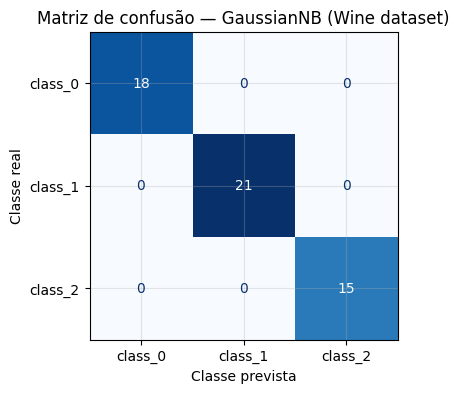

In [6]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb, display_labels=dados.target_names, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matriz de confusão — GaussianNB (Wine dataset)")
ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')
plt.show()

Deve-se ressaltar que embora o Naive Bayes seja, em geral, um bom classificador (costuma acertar a classe correta com boa frequência), ele é um estimador de probabilidades pouco calibrado. Ou seja, os valores de probabilidade retornados pelo modelo não devem ser interpretados como probabilidades reias e precisas, mas sim como uma "indicação relativa" de confiança entre as classes.

Esclarecendo o dito anteriormente, um "bom classificador, mas que é mal calibrado" significa que pode-se confiar na **classe** que o modelo denominou, mas não deve-se confiar no **valor numérico exato** da probabilidade que ele denomina para essa escolha. 

Antes de irmos para a próxima aplicação, vamos comparar o modelo `GaussianNB` com um modelo baseline.

In [7]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train_esc, y_train)
acc_baseline = accuracy_score(y_test, baseline.predict(X_test_esc))

print(f"Acurácia do baseline (classe majoritária): {acc_baseline:.3f}")
print(f"Acurácia do GaussianNB:                    {acc_gnb:.3f}")

Acurácia do baseline (classe majoritária): 0.389
Acurácia do GaussianNB:                    1.000


Como pode ser visto, o `GaussianNB` supera o modelo de baseline que sempre preve a classe majoritária, nos mostrando que o modelo está de fato aprendendo um padrão útil com base nos dados e não apenas repetindo um padrão observado (nesse caso sendo a classe mais comum).

#### 2. Aplicação em dados de texto: mensagens de spam

Uma das aplicações mais comuns do Naive Bayes é a filtagrem de spam. Para ilustrar como esse processo funciona, foi construido uma pequena relação de duas listas que contêm mensagens recebidas e se elas são spam ou não. A partir desses dados, treinamos um modelo `MultinomialNB`, esse que modela a contagem de palavras em cada mensagem.

In [8]:
mensagens = [
    "promoção imperdível clique aqui e ganhe um prêmio agora",
    "reunião de equipe marcada para amanhã às dez horas",
    "você ganhou um prêmio clique aqui para resgatar agora mesmo",
    "segue em anexo o relatório da reunião de ontem",
    "oferta exclusiva apenas hoje clique e garanta seu desconto",
    "lembrete da aula de aprendizado de máquina de amanhã",
    "ganhe dinheiro rápido clique neste link agora mesmo",
    "segue a pauta da próxima reunião do projeto",
    "prêmio garantido clique já e não perca essa chance",
    "professor enviou o material da próxima aula por aqui",
]
rotulos = [
    "spam", "não spam", "spam", "não spam", "spam",
    "não spam", "spam", "não spam", "spam", "não spam",
]

vetorizador = CountVectorizer()
X_texto = vetorizador.fit_transform(mensagens)

modelo_mnb = MultinomialNB()
modelo_mnb.fit(X_texto, rotulos)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Agora com o modelo treinado, vamos ver como ele responde a novas mensagens.

In [9]:
novas_mensagens = [
    "clique aqui agora e ganhe seu prêmio exclusivo",
    "segue o resumo da reunião de hoje com a equipe",
]
X_novas = vetorizador.transform(novas_mensagens)
previsoes = modelo_mnb.predict(X_novas)

for msg, classe in zip(novas_mensagens, previsoes):
    print(f"'{msg}'  ->  {classe}")

'clique aqui agora e ganhe seu prêmio exclusivo'  ->  spam
'segue o resumo da reunião de hoje com a equipe'  ->  não spam


Vemos que mesmo com poucos dados de aprendizado (10 mensagens), o modelo captura um padrão de quais palavras são mais comuns em textos de spam. Em uma aplicação real, o conjunto de dados de treino seria muito maior e com uma maior variedade de vocabulário, mas o princípio de funcionamento é o mesmo. 

### Análise de hiperparâmetros 

Hiperparâmetros são variáveis de configuração externa definidas antes do início do treinamento de um modelo, controlando como o aprendizado irá acontecer. Em outras palavras, os hiperparâmetros são definidos manualmente pelo cientista de dados e funcionam como uma receita para o modelo seguir para que ele aprenda do jeito desejado.

O hiperparâmetro mais conhecido é o `alpha` do `MultinomialNB`, que é nada mais que o termo de suavização de Laplace discutido anteriormente. Já o `GaussianNB` tem um hiperparâmetro menos conhecido, o `var_smoothin`, que adiciona uma fração da maior variância encontrada entre todos os atributos à variância de cada atributo, evitando problemas numéricos quando a variância de algum atributo é muito próximo de zero. 

Agora, vamos observar como a acurácia de validação cruzada do `GaussianNB` no conjunto de vinhos varia ao mudarmos o `var_smoothing`.

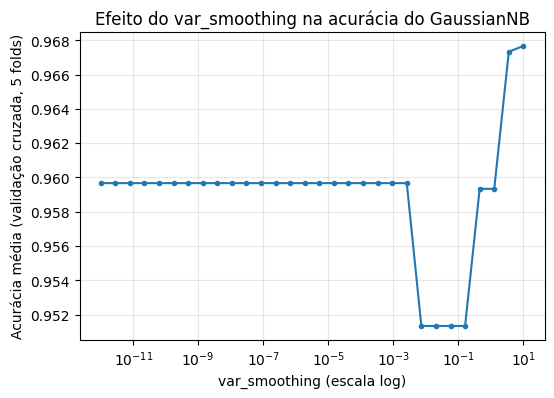

Melhor var_smoothing testado: 1.00e+01
Acurácia (CV) correspondente: 0.968


In [10]:
valores_smoothing = np.logspace(-12, 1, 30)
acuracias_cv = []

for vs in valores_smoothing:
    modelo = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(modelo, X_train_esc, y_train, cv=5, scoring="accuracy")
    acuracias_cv.append(scores.mean())

fig, ax = plt.subplots()
ax.plot(valores_smoothing, acuracias_cv, marker="o", markersize=3)
ax.set_xscale("log")
ax.set_xlabel("var_smoothing (escala log)")
ax.set_ylabel("Acurácia média (validação cruzada, 5 folds)")
ax.set_title("Efeito do var_smoothing na acurácia do GaussianNB")
plt.show()

melhor_idx = int(np.argmax(acuracias_cv))
print(f"Melhor var_smoothing testado: {valores_smoothing[melhor_idx]:.2e}")
print(f"Acurácia (CV) correspondente: {acuracias_cv[melhor_idx]:.3f}")

Como é possível ver pelo gráfico, para a maior parte da faixa de valores baixos e moderados do `var_smoothing`, a acurácia se mantém estável, fato que é esperado, visto que o conjunto de dados *Wine* não possui atributos com variâncias próximas de zero. Já quando o `var_smoothing` cresce muito, aproximando-se a valores próximos à ordem de grandezas das próprias variâncias dos atributos, o modelo passa a distorcer as distribuições guassianas de cada classe, tornando-as mais parecidas entre si e degrandando a capacidade de separação, o que evidencia o efeito de regularização do hiperparâmetro.

### Visualização interativa

Para tornar mais concreto o efeito do `var_smoothing`, construímos uma visualização interativa: usando apenas dois atributos do conjunto de vinhos (para poder desenhar a fronteira em 2D), é possível arrastar um controle deslizante e observar como a fronteira de decisão entre as classes se transforma conforme o valor de `var_smoothing` aumenta.

In [11]:
idx_attrs = [dados.feature_names.index("alcohol"), dados.feature_names.index("color_intensity")]
X2 = X_train_esc[:, idx_attrs]
y2 = y_train

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx2, yy2 = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))


def plota_fronteira(var_smoothing_exp=0.0):
    '''Treina um GaussianNB 2D com var_smoothing = 10**var_smoothing_exp e plota a fronteira.'''
    vs = 10 ** var_smoothing_exp
    modelo2d = GaussianNB(var_smoothing=vs)
    modelo2d.fit(X2, y2)
    Z2 = modelo2d.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.contourf(xx2, yy2, Z2, alpha=0.25, cmap="viridis")
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="viridis", edgecolor="k", s=25)
    ax.set_xlabel("teor alcoólico (padronizado)")
    ax.set_ylabel("intensidade de cor (padronizado)")
    ax.set_title(f"var_smoothing = {vs:.1e}")
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display

    slider = widgets.FloatSlider(
        value=0.0, min=-6.0, max=2.0, step=0.5,
        description="log10(var_smoothing):",
        style={"description_width": "initial"},
        continuous_update=False,
    )
    saida_interativa = widgets.interactive_output(plota_fronteira, {"var_smoothing_exp": slider})
    display(slider, saida_interativa)

except ImportError:
    print("ipywidgets não disponível neste ambiente — mostrando uma grade estática de comparação.\n")
    for expoente in [-6, -1, 1, 2]:
        plota_fronteira(expoente)

FloatSlider(value=0.0, continuous_update=False, description='log10(var_smoothing):', max=2.0, min=-6.0, step=0…

Output()

À medida que o valor de `var_smoothing` aumenta, o modelo considera distribuições mais "largas" e menos sensíveis às variações específicas dos dados de treinamento, tornando as fronteiras de decisão mais suaves e robustas. Por outro lado, valores muito pequenos fazem com que o classificador dependa mais das variâncias originais, gerando fronteiras mais sensíveis aos dados e potencialmente mais suscetíveis a ruídos. Assim, o gráfico permite visualizar em tempo real como a escolha desse hiperparâmetro influencia a separação das classes e o comportamento do modelo.

### Comparação com o modelo KNN

Algo interessante a se fazer é comparar o Naive Bayes com o modelo de K-vizinhos mais próximos (KNN), um famoso algoritmo de classificação. 

O `GaussianNB` é um modelo generativo e paramétrico; isso significa que ele resume cada classe a apenas dois parâmetros por atributo, sendo esses a média e o desvio padrão, e assume que os atributos são condicionalmente independentes entre si. Já o `KNN` é um algoritmo não paramétrico e baseado em instâcias, de modo que ele não assume nenhuma distribuição para os dados nem "resume" o treino em parâmetros; ao invés disso, ele guarda todos os exemplos de treino e classifica um novo ponto pela maioria de "votos" de seus $K$ vizinhos mais próximos.

Essa diferença tem um impacto direto no custo computacional. O `GaussianNB` tem um treino muito rápido, bastando apenas calcular a média e o desvio padrão, e possui uma predição quase que instantânea. Já o `KNN` não tem uma fase de treino definida, ele apenas armazena os dados, o que deveria diminuir seu custo computacional, mas na realidade esse "preço poupado" é gasto na hora de prever, de modo que ele precisa calcular a distância do novo ponto até todos os outros pontos. Devemos ressaltar também que o `KNN` é mais sensível à escala de atributos e à escolha do hiperparâmetro $K$ (número de vizinhos), de mesma maneira que o `GaussianNB` é sensível ao seu hiperparâmetro `var_smoothing`.

Agora iremos comparar ambos os algoritmos no mesmo conjunto de dados, *Wine*, usando validação cruzada. 

In [12]:
modelos = {
    "GaussianNB": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

resultados = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_esc, y_train, cv=5, scoring="accuracy")
    resultados[nome] = scores
    print(f"{nome:22s}: acurácia média = {scores.mean():.3f}  (desvio-padrão = {scores.std():.3f})")

GaussianNB            : acurácia média = 0.960  (desvio-padrão = 0.025)
KNN (k=5)             : acurácia média = 0.967  (desvio-padrão = 0.031)


E agora plotaremos um gráfico para melhor visualização.

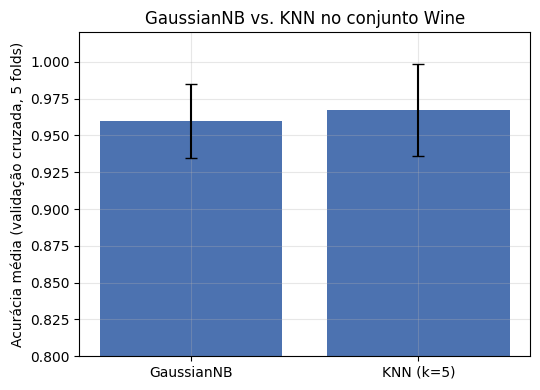

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 4))
nomes = list(resultados.keys())
medias = [resultados[n].mean() for n in nomes]
desvios = [resultados[n].std() for n in nomes]

ax.bar(nomes, medias, yerr=desvios, capsize=4, color="#4C72B0")
ax.set_ylabel("Acurácia média (validação cruzada, 5 folds)")
ax.set_title("GaussianNB vs. KNN no conjunto Wine")
ax.set_ylim(0.8, 1.02)
plt.tight_layout()
plt.show()

Ao analisar esse conjunto de dados, que pode ser considerado relativamente bem comportado, vemos um desempenho competitivo entre os algoritmos. Isso acontece pois os atributos químicos, após a padronização, se aproximam de distribuições normais dentro de cada classe. 

Porém, a vantagem prática do `GaussianNB` não é mostrada nesse gráfico. Essa vantagem é nada menos do que seu período de treinamento, que já foi discutido anteriormente, que consiste em apenas calcular a média e o desvio padrão por atributo por classe, sem precisar guardar todo o conjunto de treino nem calcular distâncias par a par no momento de previsão, como faz o `KNN`. 

Essa relação entre desempenho competitivo e baixo custo computacional é exatamente o que torna o Naive Bayes uma ótima escolha como modelo de referência inicial (baseline) antes de investir em algoritmos mais sofisticados. 

### Vantagens e limitações

#### Vantagens

- É um algoritmo simples, rápido de treinar e com poucos hiperparâmetros;
- Não precisa de muitos dados de treino;
- Baixo custo computacional; 
- Lida bem com dados de alta dimensionalidade, visto que cada atributo é lidado com de forma independente;
- Mesmo que assuma independência entre as variáveis, ele comumente entrega resultados precisos;
- É de fácil interpretação, visto que é muito nítido o que cada variável faz e como ela contribui para um resultado específico;
- É muito versátil, podendo ser aplicado em diversos contextos.

#### Limitações 

- A suposição de independência condicional é uma raridade na vida real, de modo que não podem ser interpretadas separadas tão facilmente;
- Sofre com o problema de frequência zero se não for feita uma suavização adequada;
-  As variantes discretas, como a `Multinomial` e a `Bernoulli`, funcionam melhor com dados categóricos/discretos do que com dados contínuos;
-  As probabilidades estimada pelo modelo não são bem calibradas, de modo que o Naive Bayes costuma ser um bom classificador mas um ruim estimador.

### Conclusão

O Naive Bayes transforma problemas de classificação computacionalmente caros em um cálculo simples e rápido (produto de distribuições unidimensionais), a custo de assumir independência condicional entre os atributos. Mesmo essa sendo uma suposição pouco realista nos problemas reais, o algoritmo costuma apresentar um bom desempenho.

A diferentes variantes (Gaussiana, Multinomial, Bernoulli, entre outras) permitem adaptar o algoritmo a diferentes tipos de dados, podendo ser contínuos, discretos, binários ou categóricos. Além disso, o uso do hiperparâmetro de suavização regulariza os dados, evitando problemas de frequência zero e controlando o compromisso entre viés e variância do modelo.

Ao comparar com o modelo `KNN`, o Naive Bayes se destaca, não necessariamente por ter maior acurácia, mas sim pela combinação de simplicidade, velocidade de treino e predição e bom desempenho, o tornando uma ótima ferramenta para aplicação em grandes conjuntos de dados. 

### Interação com IA

Partes desse notebook foram elaboradas com o auxílio de Inteligência Articial, como Claude e Copilot. A IA foi utilizada para:
- Escrever e organizar os códigos em python (`scikit-learn`, `matplotlib` e `ipywidgets`) para a criação dos gráficos de visualização das teorias explicadas. Vale ressaltar que todos os códigos foram revisados e melhor organizados e comentados pelo autor desse notebook;
- Discutir sobre o conteúdo desse notebook;
- Tirar dúvidas que surgiram durante a elaboração desse material;
- Formatar fórmulas em formato LaTeX;
- Formatar as referências em formato ABNT.

### Referências

1. CASSAR, Daniel R. Aprendizado de máquina, k-NN e métricas. Notas de aula (material didático) — Disciplina Aprendizado de Máquina, Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), Campinas, 2026. 1 notebook Jupyter.
2. CASSAR, Daniel R. Divisão de dados em treino e teste. Notas de aula (material didático) — Disciplina Aprendizado de Máquina, Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), Campinas, 2026. 1 notebook Jupyter.
3. IBM. Naive Bayes. IBM Think. Disponível em: <https://www.ibm.com/think/topics/naive-bayes>. Acesso em: 6 set. 2026.
4. LOW-CODE FOR ADVANCED DATA SCIENCE. An Introduction to the Naive Bayes Classifier and How to Use It. Medium. Disponível em: <https://medium.com/low-code-for-advanced-data-science/an-introduction-to-the-naive-bayes-classifier-and-how-to-use-it-bba78826ef8f>. Acesso em: 6 set. 2026.
5. ML ENGINEER. Joint Probability vs Conditional Probability. Medium. Disponível em: <https://medium.com/@mlengineer/joint-probability-vs-conditional-probability-fa2d47d95c4a>. Acesso em: 6 set. 2026.
6. SCIKIT-LEARN. 1.9. Naive Bayes. Scikit-learn Documentation. Disponível em: <https://scikit-learn.org/stable/modules/naive_bayes.html>. Acesso em: 6 set. 2026.
7. TRAIN IN DATA. Hyperparameters in Machine Learning. Train in Data Blog. Disponível em: <https://www.blog.trainindata.com/hyperparameters-in-machine-learning/>. Acesso em: 6 set. 2026.
8. VANDERPLAS, Jake. In Depth: Naive Bayes Classification. Python Data Science Handbook. Disponível em: <https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html>. Acesso em: 6 set. 2026.
9. WIKIPÉDIA. Validação cruzada. Wikipédia, a enciclopédia livre. Disponível em: <https://pt.wikipedia.org/wiki/Valida%C3%A7%C3%A3o_cruzada>. Acesso em: 6 set. 2026.